<a href="https://colab.research.google.com/github/Viktoriia-code26/goit_data_ML_Hw_5/blob/main/Hw5ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  Загрузка данных
from google.colab import drive
drive.mount('/content/drive')
import zipfile
import os

zip_path = "/content/drive/MyDrive/homework.zip"
extract_path = "/content/homework"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Архив распакован!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Архив распакован!


In [ ]:
print(os.listdir("/content/homework/data"))

['walking', 'running', 'stairs', 'idle']


In [ ]:
import pandas as pd
import glob


data_path = "/content/homework/data"
all_data = []

for activity in ["walking", "running", "stairs", "idle"]:
    folder_path = os.path.join(data_path, activity)
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    print(activity, "files:", len(csv_files))

    for file_path in csv_files:
        temp_df = pd.read_csv(file_path)

        temp_df["activity"] = activity
        temp_df["source_file"] = os.path.basename(file_path)

        all_data.append(temp_df)

if not all_data:
    raise ValueError("CSV-файлы не найдены")

df = pd.concat(all_data, ignore_index=True)

print("Размер датасета:", df.shape)
display(df.head())
print(df["activity"].value_counts())

walking files: 1850
running files: 3408
stairs files: 165
idle files: 1039
Размер датасета: (193860, 5)


,accelerometer_X,accelerometer_Y,accelerometer_Z,activity,source_file
0,-1.158794,13.891158,-3.390190,walking,walking-1723.csv
1,5.391742,-13.579912,-4.611232,walking,walking-1723.csv
2,-1.810016,-8.954314,-5.597643,walking,walking-1723.csv
3,3.533842,-10.338163,-6.469133,walking,walking-1723.csv
4,-2.413355,-1.862689,4.917691,walking,walking-1723.csv


activity
running    102240
walking     55500
idle        31170
stairs       4950
Name: count, dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193860 entries, 0 to 193859
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   accelerometer_X  193860 non-null  float64
 1   accelerometer_Y  193860 non-null  float64
 2   accelerometer_Z  193860 non-null  float64
 3   activity         193860 non-null  object 
 4   source_file      193860 non-null  object 
dtypes: float64(3), object(2)
memory usage: 7.4+ MB


In [ ]:
df.describe()

,accelerometer_X,accelerometer_Y,accelerometer_Z
count,193860.000000,193860.000000,193860.000000
mean,1.923550,1.598343,1.804896
std,8.404867,12.474041,7.191590
min,-39.188293,-39.188293,-39.188293
25%,-2.494758,-8.327033,-2.494758
50%,0.248997,-0.009577,0.905008
75%,4.668694,8.671799,7.187394
max,39.188293,39.188293,39.188293


In [ ]:
df["activity"].value_counts()

,count
activity,
running,102240
walking,55500
idle,31170
stairs,4950


In [ ]:
import numpy as np
import pandas as pd

# Уникальный идентификатор одной записи
df["record_id"] = df["activity"] + "/" + df["source_file"]

# Полная величина ускорения
df["magnitude"] = np.sqrt(
    df["accelerometer_X"] ** 2
    + df["accelerometer_Y"] ** 2
    + df["accelerometer_Z"] ** 2
)

raw_columns = [
    "accelerometer_X",
    "accelerometer_Y",
    "accelerometer_Z"
]

signal_columns = raw_columns + ["magnitude"]
features = features.reset_index()

In [ ]:
# Time-domain features
features = (
    df.groupby(["record_id", "activity"])[signal_columns]
      .agg(["mean", "std", "min", "max", "median"])
)

features.columns = [
    f"{column}_{statistic}"
    for column, statistic in features.columns
]

features = features.reset_index()

In [ ]:
# Raw features
raw_features = (
    df.groupby(["record_id", "activity"], sort=False)[raw_columns]
      .apply(lambda group: group.to_numpy().ravel())
)

raw_features = pd.DataFrame(
    raw_features.tolist(),
    index=raw_features.index
).reset_index()

In [ ]:
n_steps = len(raw_features.columns) - 2

raw_feature_names = []

for step in range(n_steps // 3):
    raw_feature_names.extend([
        f"X_t{step}",
        f"Y_t{step}",
        f"Z_t{step}"
    ])

raw_features.columns = [
    "record_id",
    "activity",
    *raw_feature_names
]

In [ ]:
print("Time-domain features:", features.shape)
print("Raw features:", raw_features.shape)

display(features.head())
display(raw_features.head())

Time-domain features: (6462, 22)
Raw features: (6462, 92)


,record_id,activity,accelerometer_X_mean,accelerometer_X_std,accelerometer_X_min,accelerometer_X_max,accelerometer_X_median,accelerometer_Y_mean,accelerometer_Y_std,accelerometer_Y_min,...,accelerometer_Z_mean,accelerometer_Z_std,accelerometer_Z_min,accelerometer_Z_max,accelerometer_Z_median,magnitude_mean,magnitude_std,magnitude_min,magnitude_max,magnitude_median
0,idle/idle-1.csv,idle,0.178448,1.036361,-0.909797,5.099650,-0.102950,0.167435,1.157603,-0.282516,...,9.605697,0.406903,8.418014,9.806650,9.770737,9.736895,0.127980,9.252485,9.843344,9.774678
1,idle/idle-10.csv,idle,-0.098641,0.125848,-0.320823,0.407014,-0.114922,-0.131202,0.048059,-0.244209,...,9.771216,0.025419,9.667787,9.806650,9.777920,9.773491,0.026003,9.670041,9.815122,9.779389
2,idle/idle-100.csv,idle,-0.099918,0.015642,-0.124498,-0.062249,-0.100556,0.220905,0.016383,0.177171,...,9.768503,0.014528,9.739613,9.792285,9.768343,9.771537,0.014427,9.743125,9.795601,9.771424
3,idle/idle-1000.csv,idle,0.400949,0.052889,0.268151,0.560243,0.392649,-0.029528,0.054525,-0.205901,...,9.752541,0.017967,9.725247,9.797073,9.751583,9.761108,0.019205,9.729325,9.815238,9.760844
4,idle/idle-1001.csv,idle,0.400949,0.053187,0.268151,0.560243,0.402226,-0.027134,0.054004,-0.205901,...,9.753659,0.018902,9.725247,9.797073,9.751583,9.762216,0.020038,9.729325,9.815238,9.760844


,record_id,activity,X_t0,Y_t0,Z_t0,X_t1,Y_t1,Z_t1,X_t2,Y_t2,...,Z_t26,X_t27,Y_t27,Z_t27,X_t28,Y_t28,Z_t28,X_t29,Y_t29,Z_t29
0,walking/walking-1723.csv,walking,-1.158794,13.891158,-3.390190,5.391742,-13.579912,-4.611232,-1.810016,-8.954314,...,-9.950302,1.532289,-13.986926,8.652645,1.130063,-5.851429,-13.163321,0.593762,-7.508216,1.077391
1,walking/walking-1580.csv,walking,-0.785298,-14.221559,-7.225701,-2.561796,-22.615630,-20.877440,-0.952892,-12.976573,...,3.112462,-1.115698,-11.506534,-12.287044,0.129287,-7.311892,1.517924,1.517924,-21.815966,-19.704280
2,walking/walking-1598.csv,walking,1.388637,-24.827871,-12.382812,-9.299079,-22.050598,-0.234632,-7.704541,8.298303,...,4.769250,2.154782,-13.196839,-7.738060,-2.901772,-1.383848,4.726155,0.952892,-8.523358,0.071826
3,walking/walking-747.csv,walking,-12.497733,-19.747375,-17.678785,-1.173159,-11.042058,-1.723825,-2.351106,-3.117251,...,2.710236,-10.199299,-19.479225,-7.800309,-3.572149,-10.840945,-2.600103,-0.962469,8.777143,7.498640
4,walking/walking-326.csv,walking,-3.122039,-8.949526,-1.939303,-1.584961,-0.713472,3.385401,-6.526593,-5.631162,...,-0.593762,-9.208099,-15.236700,6.057330,1.086968,-18.918982,20.398598,-1.527501,-12.722788,-0.545878


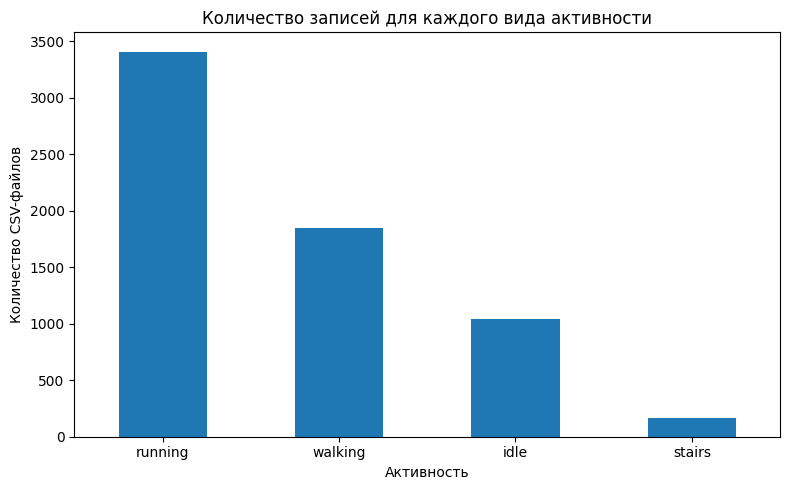

In [ ]:
import matplotlib.pyplot as plt

file_counts = (
    df[["activity", "source_file"]]
    .drop_duplicates()
    ["activity"]
    .value_counts()
)

plt.figure(figsize=(8, 5))
file_counts.plot(kind="bar")

plt.title("Количество записей для каждого вида активности")
plt.xlabel("Активность")
plt.ylabel("Количество CSV-файлов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

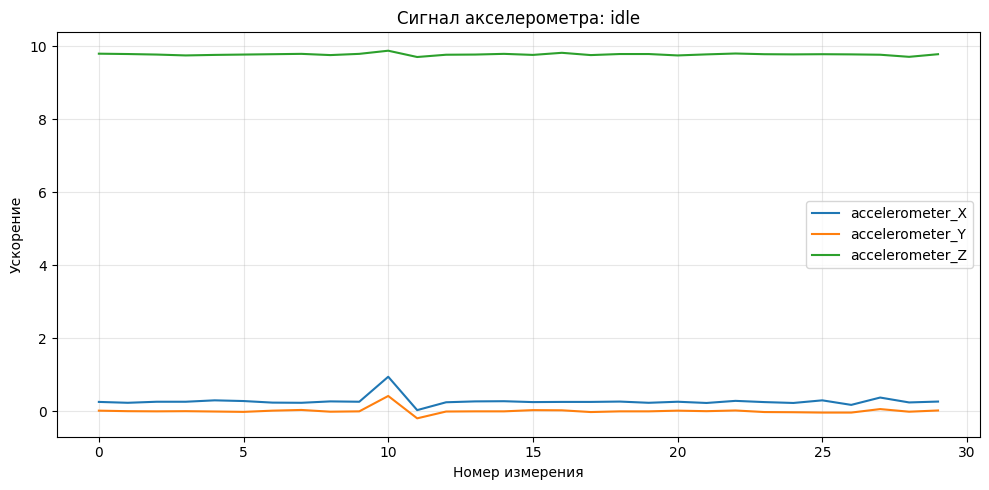

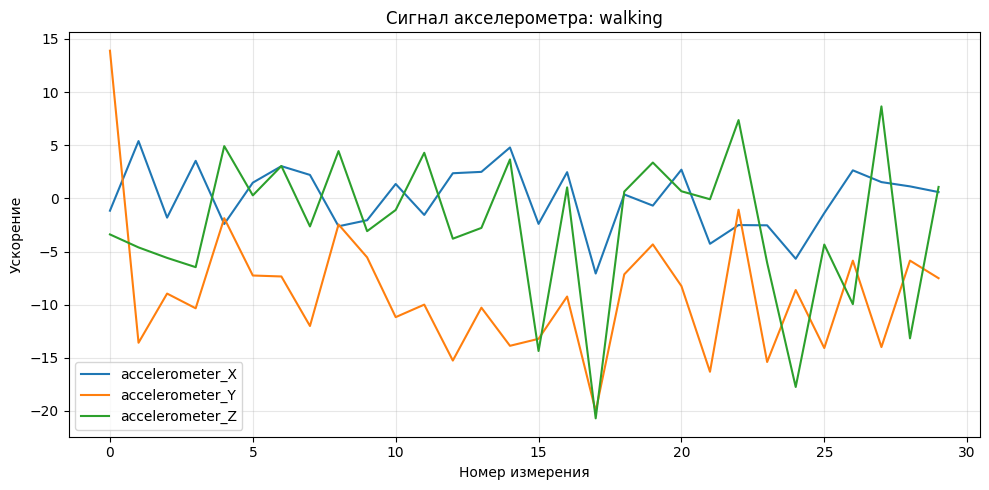

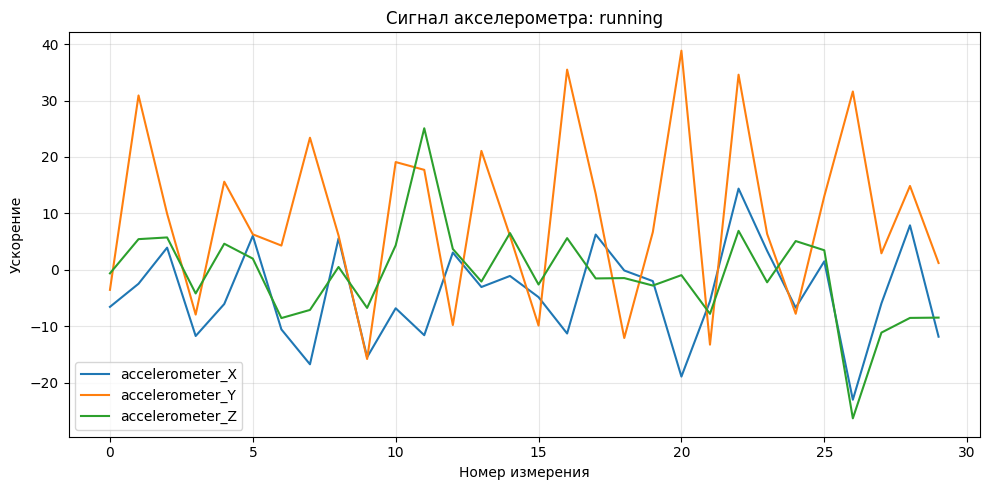

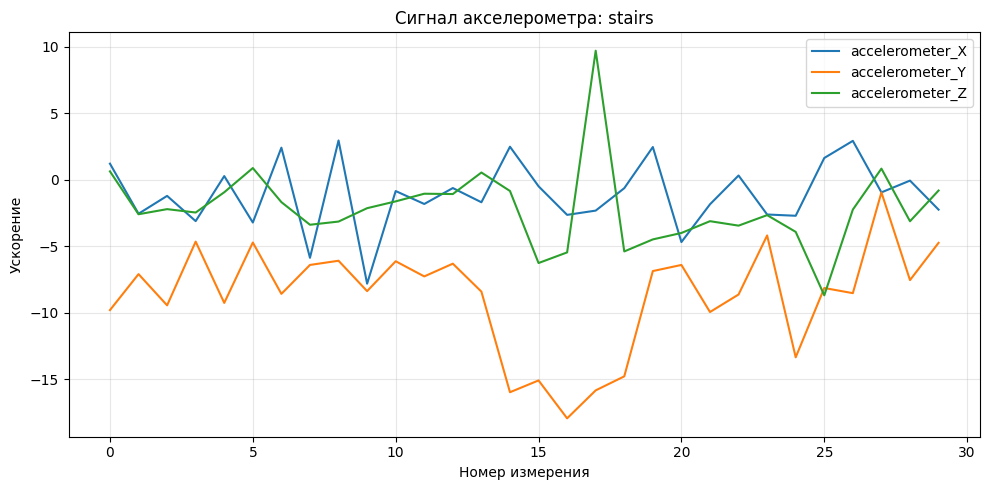

In [ ]:
axes = ["accelerometer_X", "accelerometer_Y", "accelerometer_Z"]
activities = ["idle", "walking", "running", "stairs"]

for activity in activities:
    example_file = (
        df.loc[df["activity"] == activity, "source_file"]
        .iloc[0]
    )

    sample = df[
        (df["activity"] == activity) &
        (df["source_file"] == example_file)
    ].reset_index(drop=True)

    plt.figure(figsize=(10, 5))

    for axis in axes:
        plt.plot(sample.index, sample[axis], label=axis)

    plt.title(f"Сигнал акселерометра: {activity}")
    plt.xlabel("Номер измерения")
    plt.ylabel("Ускорение")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_raw = raw_features.drop(columns=["record_id", "activity"])
y_raw = raw_features["activity"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_raw = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_raw.fit(X_train_raw, y_train_raw)
rf_raw_pred = rf_raw.predict(X_test_raw)

print(classification_report(
    y_test_raw,
    rf_raw_pred,
    digits=4
))

              precision    recall  f1-score   support

        idle     1.0000    1.0000    1.0000       208
     running     1.0000    1.0000    1.0000       682
      stairs     1.0000    0.1515    0.2632        33
     walking     0.9296    1.0000    0.9635       370

    accuracy                         0.9783      1293
   macro avg     0.9824    0.7879    0.8067      1293
weighted avg     0.9799    0.9783    0.9708      1293



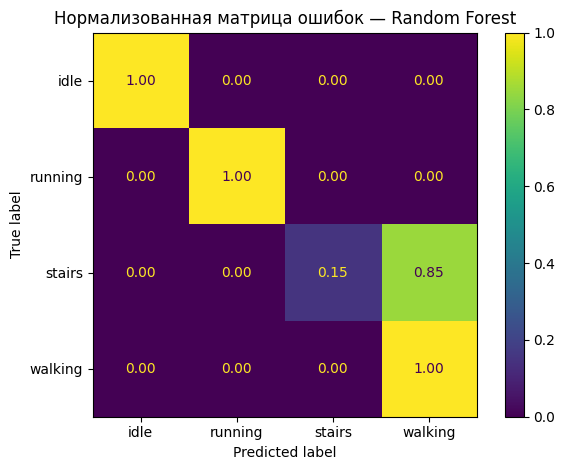

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_raw,
    rf_raw_pred,
    normalize="true",
    values_format=".2f"
)

plt.title("Нормализованная матрица ошибок — Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# SVM
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_raw = make_pipeline(
    StandardScaler(),
    SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=42
    )
)

svm_raw.fit(X_train_raw, y_train_raw)
svm_raw_pred = svm_raw.predict(X_test_raw)

print(classification_report(
    y_test_raw,
    svm_raw_pred,
    digits=4
))

              precision    recall  f1-score   support

        idle     1.0000    1.0000    1.0000       208
     running     1.0000    1.0000    1.0000       682
      stairs     0.4737    0.8182    0.6000        33
     walking     0.9827    0.9189    0.9497       370

    accuracy                         0.9722      1293
   macro avg     0.8641    0.9343    0.8874      1293
weighted avg     0.9816    0.9722    0.9754      1293



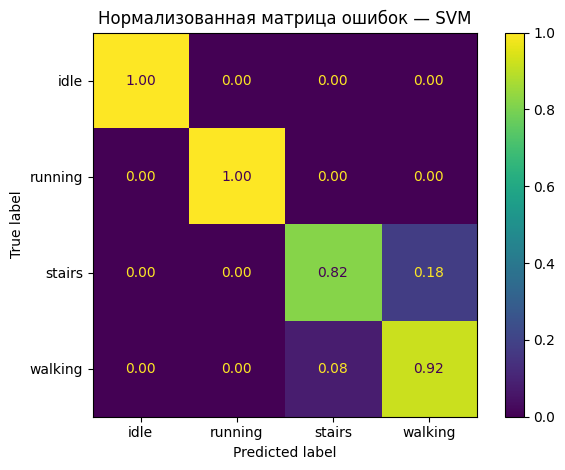

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_raw,
    svm_raw_pred,
    normalize="true",
    values_format=".2f"
)

plt.title("Нормализованная матрица ошибок — SVM")
plt.tight_layout()
plt.show()

In [ ]:
#  Сравнение результатов
from sklearn.metrics import classification_report
import pandas as pd

reports = {
    "RF — raw": classification_report(
        y_test_raw,
        rf_raw_pred,
        output_dict=True,
        zero_division=0
    ),
    "SVM — raw": classification_report(
        y_test_raw,
        svm_raw_pred,
        output_dict=True,
        zero_division=0
    ),
    "RF — time features": rf_report,
    "SVM — time features": svm_report
}

results = pd.DataFrame([
    {
        "Модель": name,
        "Accuracy": report["accuracy"],
        "Macro precision": report["macro avg"]["precision"],
        "Macro recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    }
    for name, report in reports.items()
])

results.sort_values(
    "Macro F1",
    ascending=False
)

,Модель,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
2,RF — time features,0.999227,0.999326,0.992424,0.995816,0.999221
3,SVM — time features,0.986079,0.912559,0.980938,0.938906,0.987283
1,SVM — raw,0.972158,0.864086,0.934275,0.887430,0.975403
0,RF — raw,0.978345,0.982412,0.787879,0.806675,0.970762


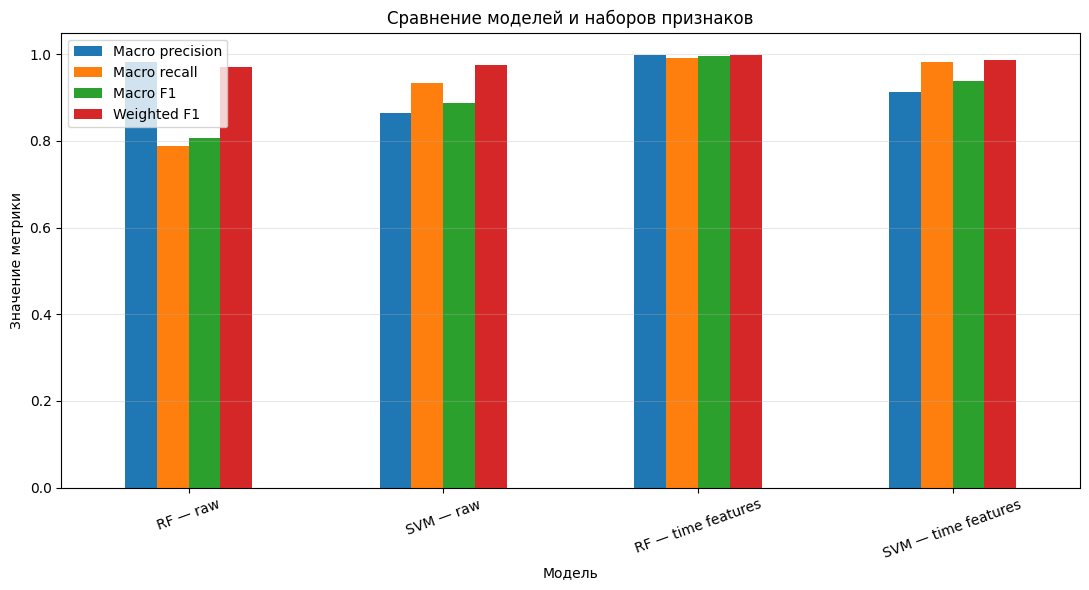

In [ ]:
results.set_index("Модель")[
    ["Macro precision", "Macro recall", "Macro F1", "Weighted F1"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Сравнение моделей и наборов признаков")
plt.ylabel("Значение метрики")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

##  Вывод

В ходе выполнения работы были обучены две модели машинного обучения: Random Forest и SVM для распознавания четырёх видов активности человека: idle, walking, running и stairs.

Для улучшения качества классификации были рассчитаны временные признаки, такие как среднее значение, стандартное отклонение, минимум, максимум, медиана, размах и RMS.

После обучения моделей результаты сравнивались с помощью classification report, где использовались метрики precision, recall и F1-score.

По полученным результатам лучше всего себя показала модель Random Forest. Она допустила всего несколько ошибок и получила самые высокие значения метрик. Модель SVM также показала хорошие результаты, но ошибалась немного чаще, особенно при распознавании активности stairs.

В целом можно сделать вывод, что для данного набора данных модель Random Forest подходит лучше, чем SVM, и обеспечивает более точную классификацию активности человека по данным акселерометра.